# LR7

### Упражнение 1

- Объедините (сложите) [синус, тренд и шум](#сигнал-с-трендом-и-шумом), которые мы определили ранее, и получите сигнал, состоящий из:
* Синусоидальной волны, представляющей сезонность.
* Параболической функции, представляющей тренд.
* и равномерно распределенного случайного шума.
- Постройте графики компонентов временной и частотной областей.
- Измените амплитуду компонентов синуса, тренда и шума так, чтобы каждый компонент, в свою очередь, доминировал над другими. Прокомментируйте, как изменяется FT общего сигнала.
- Измените синус в сигнал, который является суммой 2 синусоидальных волн разной амплитуды на 1 и 10 Гц, а также постоянного члена. Постройте графики во временной и частотной областях и прокомментируйте результаты.

### Exercise 2

- Рассмотрим зашумленный сигнал

In [ ]:
time = np.linspace(0, 5, 512)
y_sine = 2*np.sin(2 * np.pi * 0.5 * time)
y_cos = 1.5*np.cos(2 * np.pi * 2.5 * time)
y_trend = (0.5 * time)**2
y_noise = 0.8 * np.random.randn(len(time))
y_signal = y_sine + y_cos + y_trend
noisy_signal = y_signal + y_noise

- Примените [фильтр Тьюки](#tukey-filter) к `noisy_signal`.
- Измените значения `alpha` и `div_factor` фильтра, чтобы восстановить чистый сигнал `y_signal`.

### Упражнение 3

- Рассмотрим `noisy_signal` из [Упражнения 2](#exercise-2).
- Теперь ваша задача — восстановить `y_signal` с помощью [фильтра нижних частот Баттерворта](#butterworth-filter).
- Измените порядок фильтра $N$ и частоту среза $\omega_c$ фильтра Баттерворта.
- Какие значения кажутся наилучшими для устранения шума?

### Упражнение 4

- Рассмотрим `noisy_signal` из [Упражнения 2](#exercise-2).
- Теперь ваша задача - восстановить `y_signal`, а затем удалить его компонент тренда (`y_trend`).
- Для этого сначала примените [фильтр высоких частот Баттерворта](#high-pass-filters-hpfs).
- Оптимизируйте вручную порядок фильтра $N$ и частоту среза $\omega_c$ фильтра Баттерворта.
- Затем примените LPF каскадно к HPF.
- Результат не должен содержать ни тренда, ни шума.

### Упражнение 5

- Рассмотрим `noisy_signal` из [Упражнения 2](#exercise-2).
- И снова ваша задача - восстановить `y_signal`, а затем удалить его трендовую составляющую (`y_trend`).
- Оптимизируйте вручную порядок фильтра $N$ и частоты среза $\omega_c^\text{LOW}$ и $\omega_c^\text{HIGH}$ [полосового фильтра Баттерворта](#band-pass-filter).
- Сравните результат BPF с тем, что вы получили в [Упражнении 4](#exercise-4), когда вы применили HPF и LPF последовательно.

### Упражнение 6

- Рассмотрим `noisy_signal` из [Упражнения 2](#exercise-2).
- На этот раз вам придется удалить компонент `y_cos` из сигнала с помощью [полосового заграждающего фильтра](#band-stop-filter).

### Упражнение 7

- Рассмотрим данные CO2, определенные [здесь](#forecast-example-2).
- Разделите данные на обучающие и тестовые.
- Определите оптимальное количество гармоник, которое дает наилучшую MSE на тестовом наборе.

# ____________________________________________________________

Импорты и определения функций

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import signal
import statsmodels.api as sm
np.random.seed(0)

def plot_time_freq(t, y): # Временная и частотная области
    freq = np.fft.fftfreq(t.size, d=t[1]-t[0])
    Y = abs(np.fft.fft(y))
    plt.figure(figsize=[14, 3])
    plt.subplot(1, 2, 1)
    plt.plot(t, y)
    plt.title('Временная область')
    plt.xlabel('Время')
    plt.ylabel('Сигнал')
    plt.subplot(1, 2, 2)
    markerline, stemline, baseline = plt.stem(np.fft.fftshift(freq), np.fft.fftshift(Y),
                                              'k', markerfmt='tab:orange')
    plt.setp(stemline, linewidth=1.5)
    plt.setp(markerline, markersize=4)
    plt.title('Частотная область')
    plt.xlabel('Частота')
    plt.xlim(-20, 20)
    plt.ylabel('Абсолютное БПФ')
    plt.grid()
    plt.tight_layout()
    plt.show()

def filter_plot(time, y_noisy, y_clean, y_filtered, legend_names, alpha=1): # График с шумом, чистым сигналом и отфильтрованным сигналом
    plt.figure(figsize=[9, 3])
    plt.plot(time, y_noisy, 'k', lw=1)
    plt.plot(time, y_clean, 'tab:blue', lw=3)
    plt.plot(time, np.real(y_filtered), 'tab:red', linestyle='--', lw=3, alpha=alpha)
    plt.legend(legend_names)
    plt.xlabel('Время')
    plt.ylabel('Амплитуда')
    plt.tight_layout()
    plt.show()

def fourierPrediction(y, n_predict, n_harm=5): # Предсказание на основе БПФ
    n = y.size
    t = np.arange(0, n)
    p = np.polyfit(t, y, 1)
    y_notrend = y - p[0] * t - p[1]
    y_freqdom = np.fft.fft(y_notrend)
    f = np.fft.fftfreq(n)
    indexes = np.argsort(np.absolute(y_freqdom))[::-1]
    t = np.arange(0, n + n_predict)
    restored_sig = np.zeros(t.size)
    for i in indexes[:1 + n_harm * 2]:
        amp = np.absolute(y_freqdom[i]) / n
        phase = np.angle(y_freqdom[i])
        restored_sig += amp * np.cos(2 * np.pi * f[i] * t + phase)
    return restored_sig + p[0] * t + p[1]

#### Упражнение 1

Синусоидальная компонента:


<Figure size 640x480 with 0 Axes>

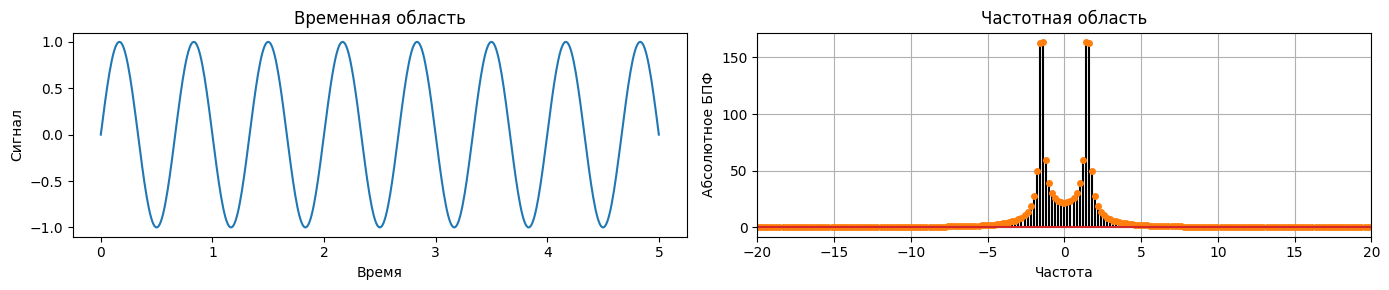

Трендовая компонента (парабола):


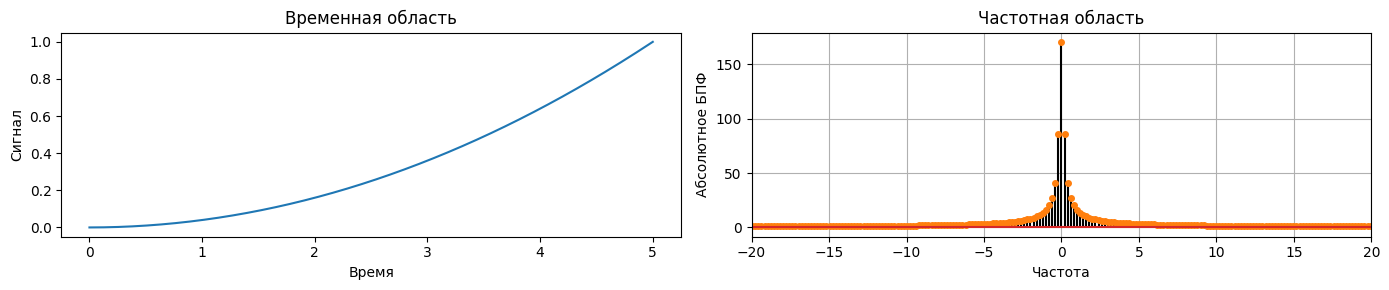

Шумовая компонента:


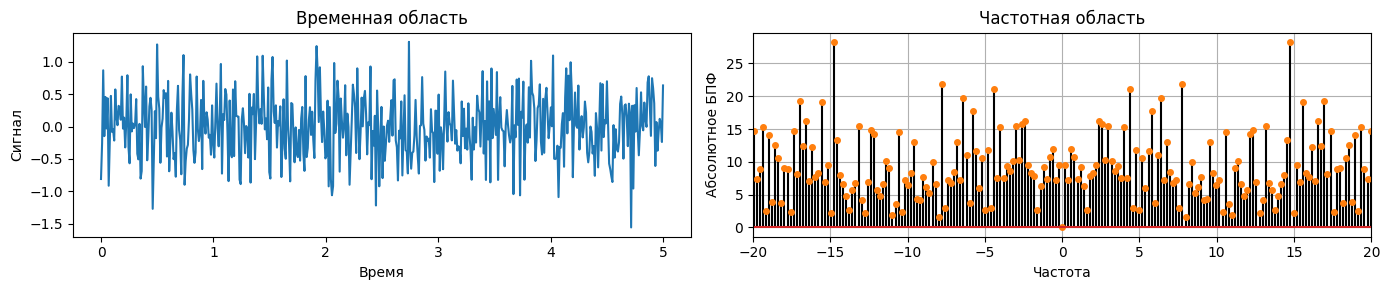

Суммарный сигнал:


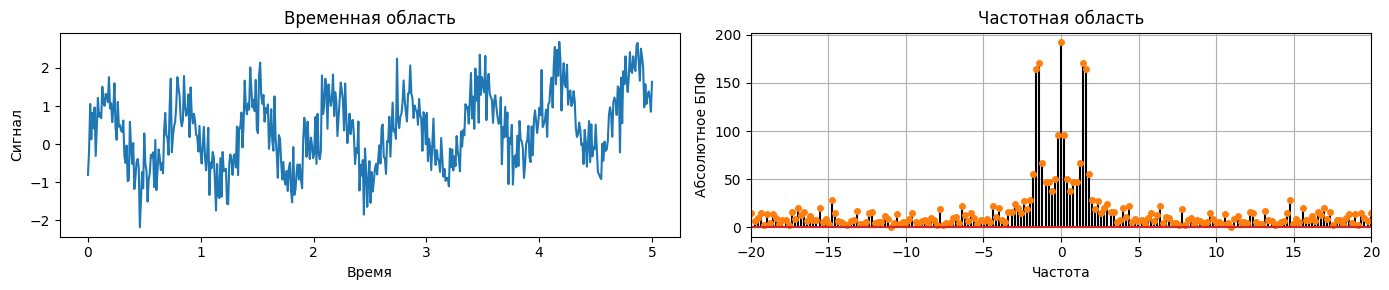

In [6]:
time = np.linspace(0, 5, 512)
freq = 1.5

y_sine  = np.sin(2 * np.pi * freq * time)
y_trend = (0.2 * time) ** 2
y_noise = 0.5 * np.random.randn(len(time))

print("Синусоидальная компонента:")
plt.suptitle('Синусоидальная компонента', y=1.02, fontsize=13)
plot_time_freq(time, y_sine)

print("Трендовая компонента (парабола):")
plot_time_freq(time, y_trend)

print("Шумовая компонента:")
plot_time_freq(time, y_noise)

print("Суммарный сигнал:")
y_combined = y_sine + y_trend + y_noise
plot_time_freq(time, y_combined)

 по Синусоидальной компоненте: (временная) чистая синусоида без искожений. (частотная) два симметричных пика. это классическое отображение синуса в Фурье (одна частота - два пика, положительная и отрицательная). Пики вокруг нуля это спектральная утечка из-за того, что сигнал не завершает ровное число периодов в окне наблюдения

 Трендовая компонента (парабола): (временная область) парабола растёт медленно и плавно от 0 до 1. Нет колебаний, только монотонный рост, типичный нелинейный тренд. (Частотная область) вся энергия сосредоточена у нуля (низкие частоты)

 Шумовая компонента: (Временная область) хаотичные быстрые колебания без видимой структуры (шум). (Частотная область) энергия распределена равномерно по всем частотам. Есть добинирующие пики на -1.5 и 1.5.

 Суммарный сигнал (Временная область) видна синусоидальная структура, колебания зашумлены и амплитуда нарастает к концу.  все три компонента одновременно видны и во временной, и в частотной области.


##### Доминирование каждого компонента по очереди

посмотрим как амплитуда компонента влияет на FT суммарного сигнала

Доминирует синус:


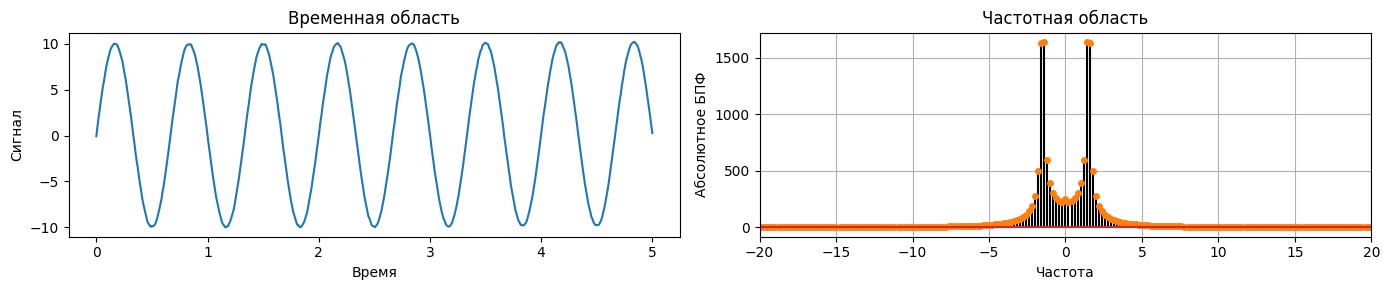

Доминирует тренд:


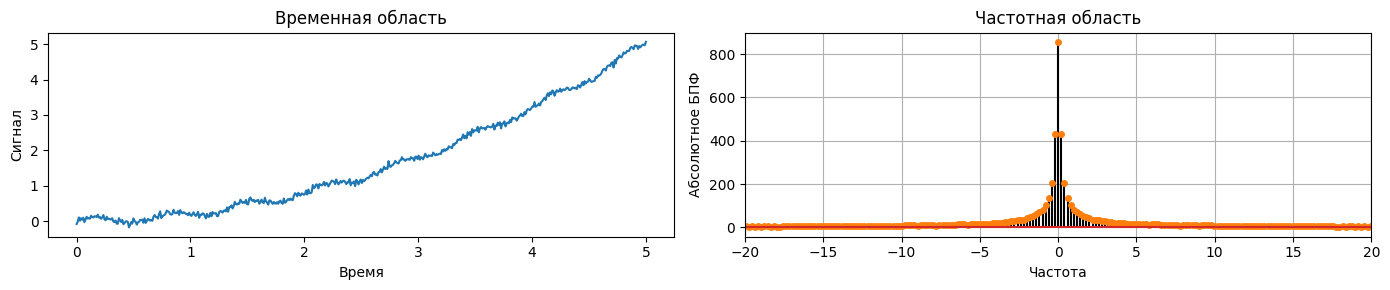

Доминирует шум:


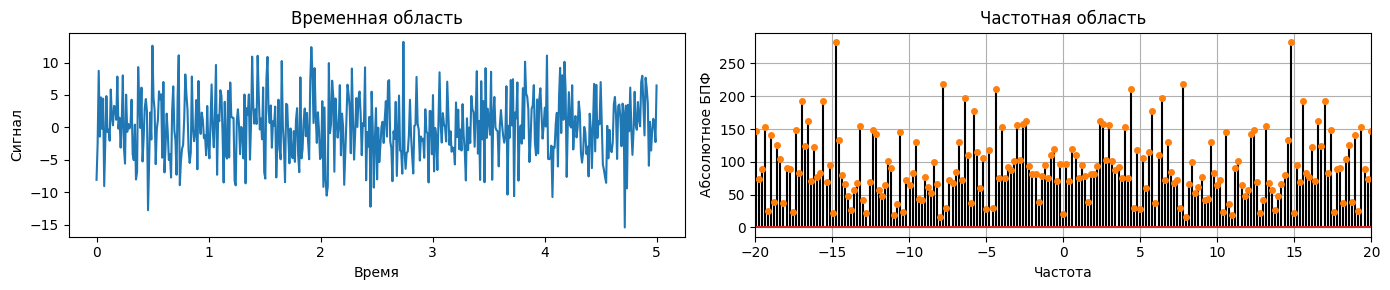

In [7]:
# 1 Доминирует синус
y_dom_sine = 10 * np.sin(2 * np.pi * freq * time) + 0.2 * y_trend + 0.1 * y_noise
print("Доминирует синус:")
plot_time_freq(time, y_dom_sine)

# 2 Доминирует тренд
y_dom_trend = 0.1 * np.sin(2 * np.pi * freq * time) + 5 * y_trend + 0.1 * y_noise
print("Доминирует тренд:")
plot_time_freq(time, y_dom_trend)

# 3 Доминирует шум
y_dom_noise = 0.1 * np.sin(2 * np.pi * freq * time) + 0.1 * y_trend + 10 * y_noise
print("Доминирует шум:")
plot_time_freq(time, y_dom_noise)

Доминирует синус: во временной области чистая синусоида, тренд и шум визуально не заметны
Частотная область - пик у нуля от тренда и фон от шума практически исчезли на фоне доминирующих пиков

Доминирует тренд: Временная область - монотонный параболический рост. Синус едва заметен в виде мелкой ряби, шум также почти не виден. Частотная область - огромный пик у нуля, всё остальное ничтожно мало

Доминирует шум: Временная область - хаотичные колебания. Синус и тренд полностью скрыты под шумом. Частотная область - равномерный широкополосный фон по всем частотам 


##### Два синуса + константа

Два синуса + константа:


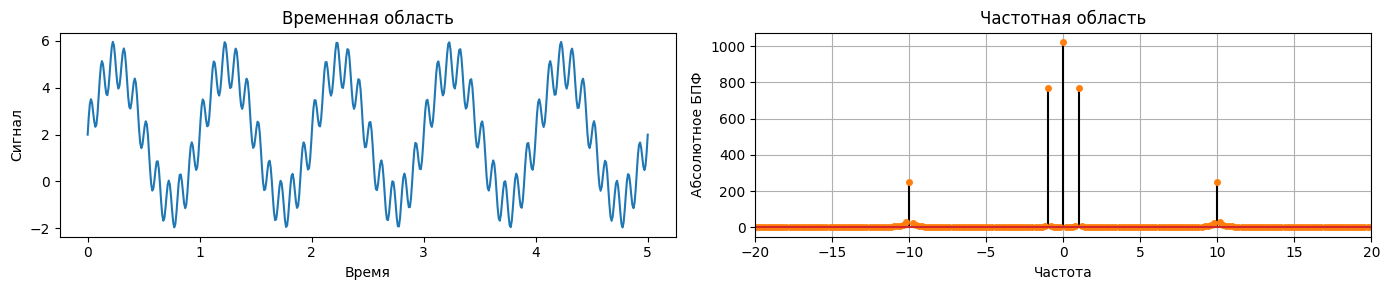

In [8]:
y_two_sines = 3 * np.sin(2 * np.pi * 1 * time) + 1 * np.sin(2 * np.pi * 10 * time) + 2
print("Два синуса + константа:")
plot_time_freq(time, y_two_sines)

Два синуса создают биение огибающую во временной области, сигнал смещён вверх на 2. В частотной области три чётких пика у нуля (константа)

### Упражнение 2

Фильтр Тьюки

Фильтр Тьюки: alpha=0.1, div=8, MSE=34700.176


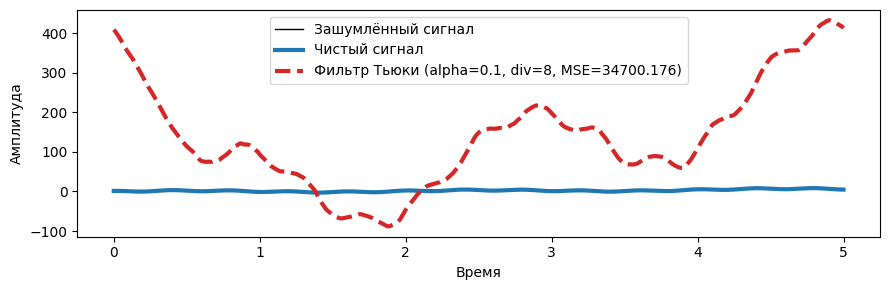

Фильтр Тьюки: alpha=0.1, div=16, MSE=8848.178


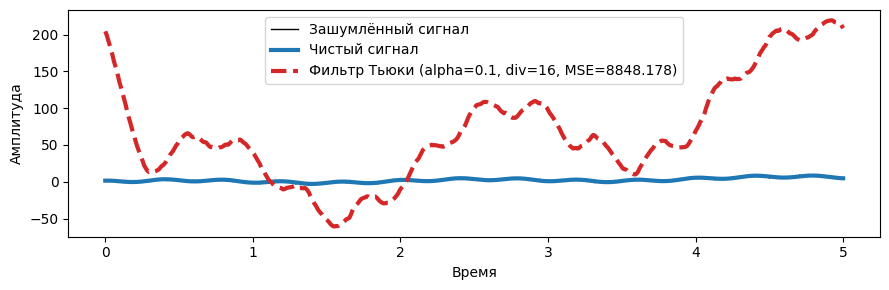

Фильтр Тьюки: alpha=0.1, div=32, MSE=2001.718


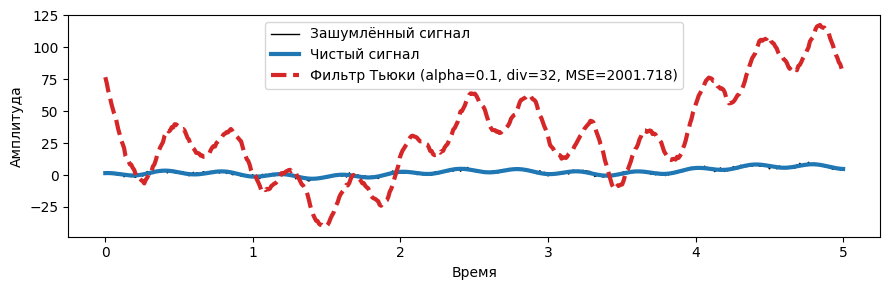

Фильтр Тьюки: alpha=0.5, div=8, MSE=22060.071


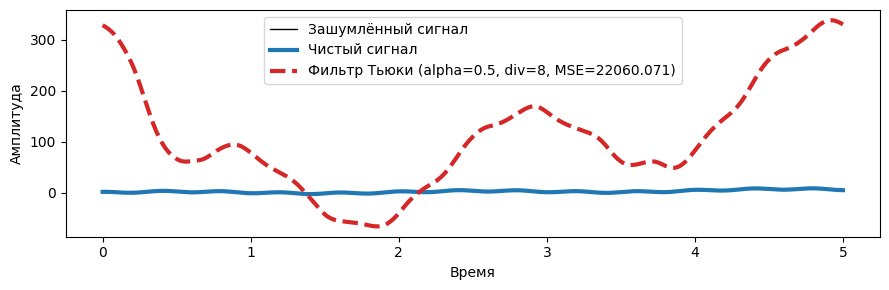

Фильтр Тьюки: alpha=0.5, div=16, MSE=5587.724


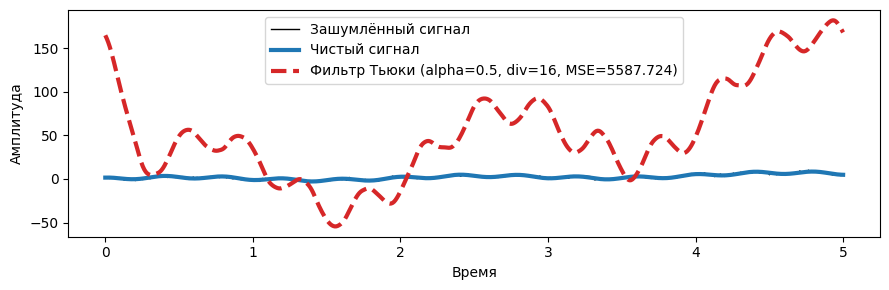

Фильтр Тьюки: alpha=0.5, div=32, MSE=1260.751


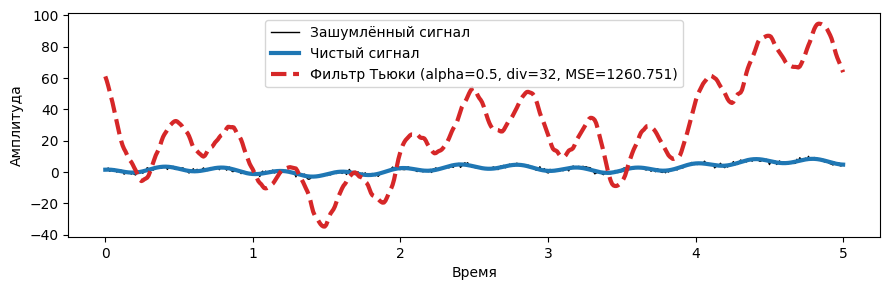

Фильтр Тьюки: alpha=1.0, div=8, MSE=9893.611


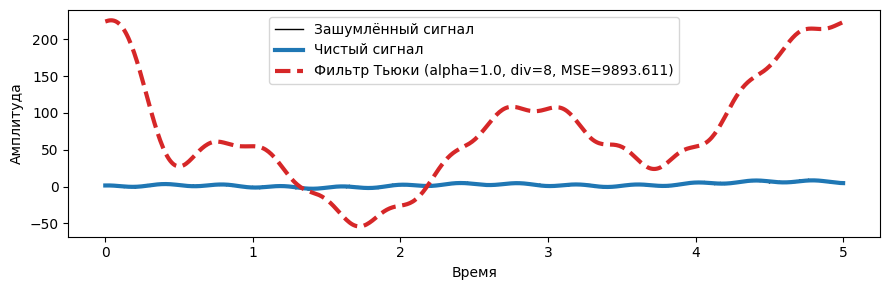

Фильтр Тьюки: alpha=1.0, div=16, MSE=2456.675


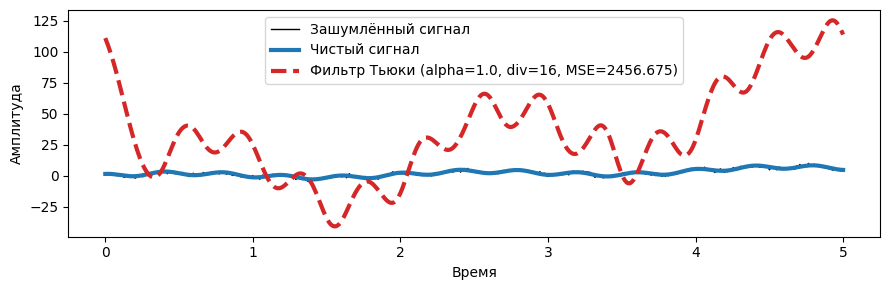

Фильтр Тьюки: alpha=1.0, div=32, MSE=516.504


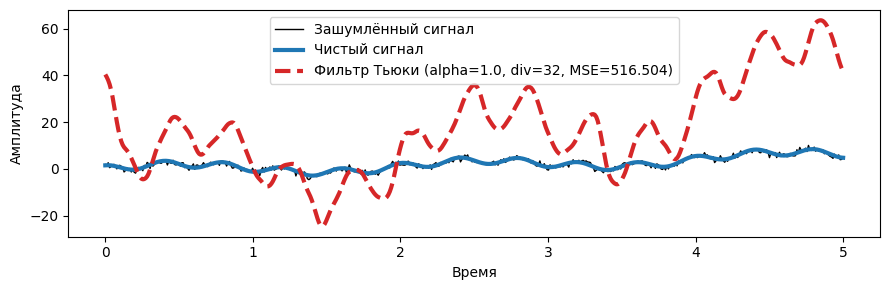


Лучшие параметры: alpha=1.0, div_factor=32, MSE=516.504


In [10]:
# Определение сигналов
time = np.linspace(0, 5, 512)
y_sine  = 2 * np.sin(2 * np.pi * 0.5 * time)
y_cos   = 1.5 * np.cos(2 * np.pi * 2.5 * time)
y_trend = (0.5 * time) ** 2
y_noise = 0.8 * np.random.randn(len(time))
y_signal    = y_sine + y_cos + y_trend
noisy_signal = y_signal + y_noise

def tukey_filter(y, alpha=0.5, div_factor=16):
    n = len(y)
    window = signal.windows.tukey(n // div_factor, alpha=alpha)
    window_padded = np.zeros(n)
    window_padded[:len(window)] = window
    Y = np.fft.fft(y)
    W = np.fft.fft(window_padded)
    return np.fft.ifft(Y * W)

# Перебор параметров
best_mse = np.inf
best_params = None

for alpha in [0.1, 0.5, 1.0]:
    for div_factor in [8, 16, 32]:
        y_filtered = tukey_filter(noisy_signal, alpha=alpha, div_factor=div_factor)
        mse = np.mean((y_signal - np.real(y_filtered)) ** 2)
        label = f'alpha={alpha}, div={div_factor}, MSE={mse:.3f}'
        print(f"Фильтр Тьюки: {label}")
        filter_plot(time, noisy_signal, y_signal, y_filtered,
                    ['Зашумлённый сигнал', 'Чистый сигнал', f'Фильтр Тьюки ({label})'])
        if mse < best_mse:
            best_mse = mse
            best_params = (alpha, div_factor)

print(f"\nЛучшие параметры: alpha={best_params[0]}, div_factor={best_params[1]}, MSE={best_mse:.3f}")

Лучшим вариантом получился alpha=1.0, div_factor=32, MSE=516.504, красная кривая хорошо повторяет форму синего сигнала, без сильных смещений и завалов

При маленьком div (8) окно узкое, фильтр слишком агрессивный, «ломает» тренд и синус, MSE огромный.При среднем div (16) становится лучше, но ещё заметно искажение формы. При большом div (32) окно длинное, фильтр мягкий, лучше сохраняет тренд и синус, при этом шум приглушается

alpha =0.1, 0.5 дают более «прямоугольное» окно, жёсткие края и хуже восстановление. alpha=1.0 (окно Ханна) даёт наиболее гладкое окно, наименее искажённый сигнал и минимальный MSE


### Упражнение 3

LPF Баттерворта: N=1, omega_c=0.03, MSE=0.205


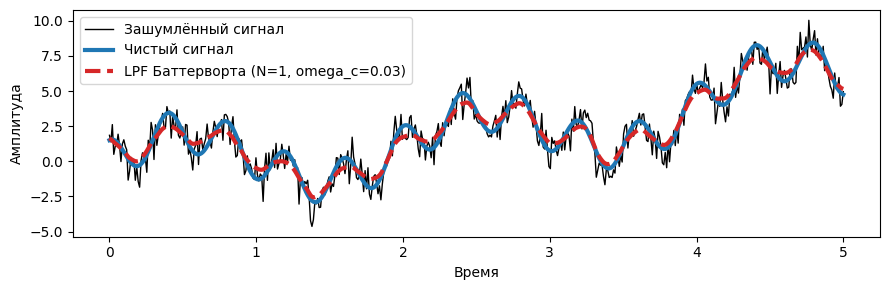

LPF Баттерворта: N=1, omega_c=0.05, MSE=0.088


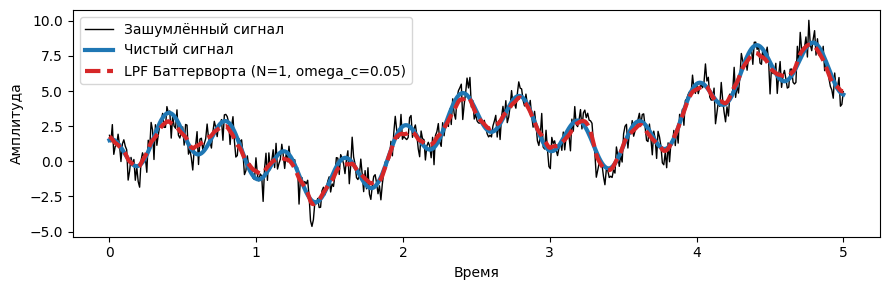

LPF Баттерворта: N=1, omega_c=0.08, MSE=0.082


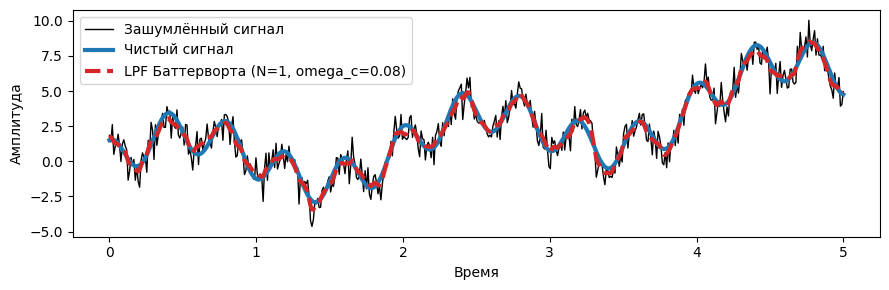

LPF Баттерворта: N=2, omega_c=0.03, MSE=0.133


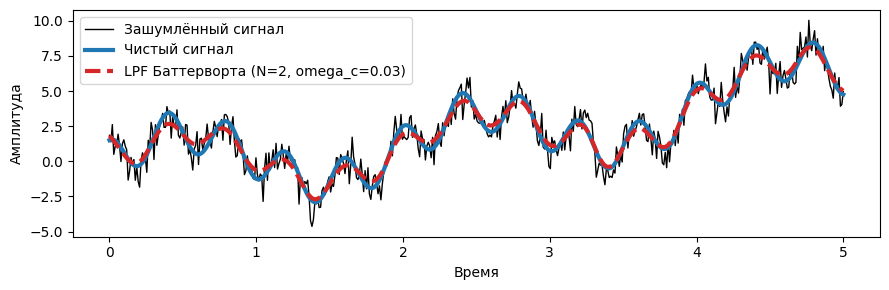

LPF Баттерворта: N=2, omega_c=0.05, MSE=0.054


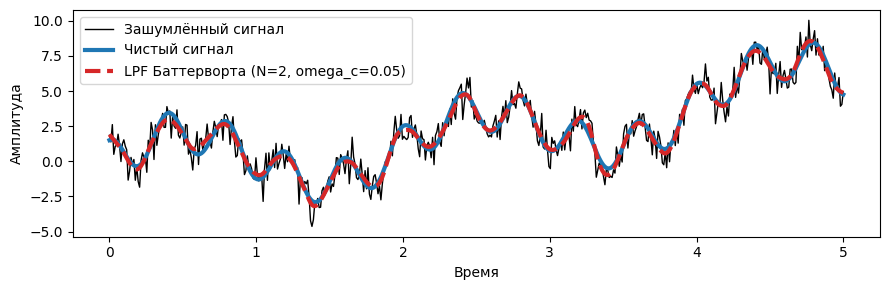

LPF Баттерворта: N=2, omega_c=0.08, MSE=0.079


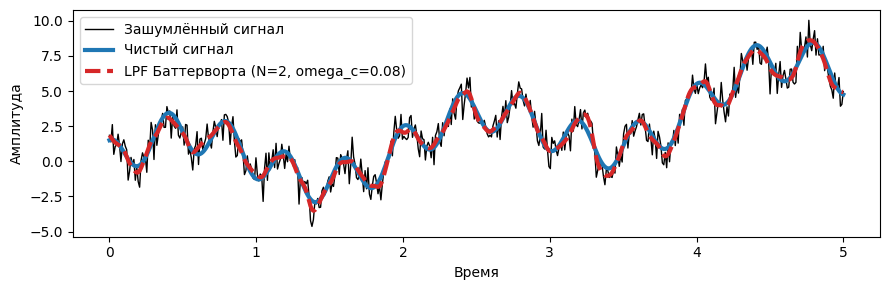

LPF Баттерворта: N=4, omega_c=0.03, MSE=0.064


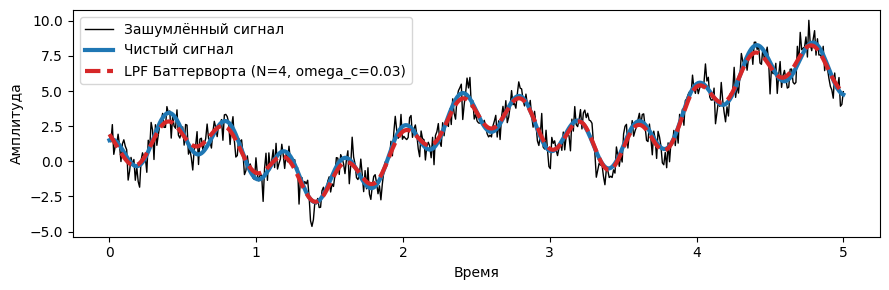

LPF Баттерворта: N=4, omega_c=0.05, MSE=0.056


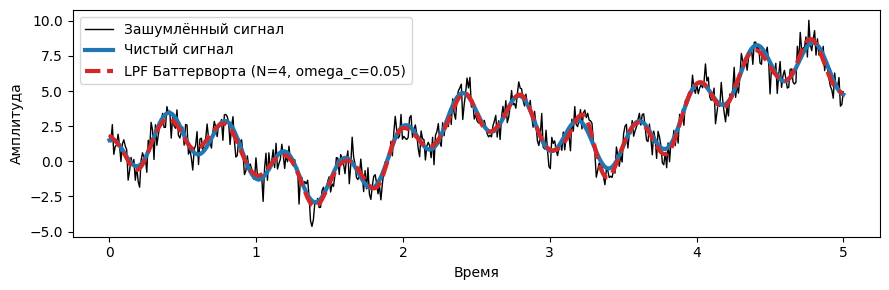

LPF Баттерворта: N=4, omega_c=0.08, MSE=0.084


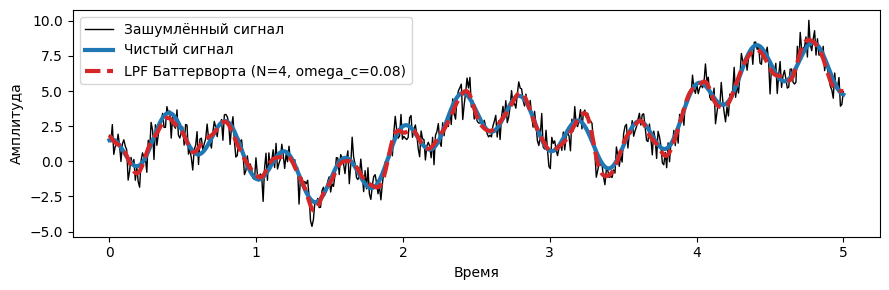

LPF Баттерворта: N=6, omega_c=0.03, MSE=0.044


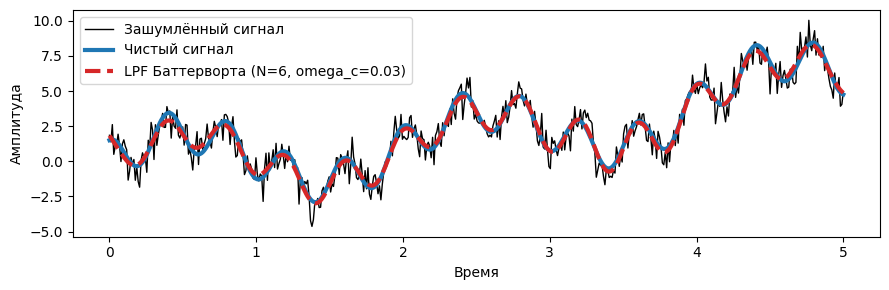

LPF Баттерворта: N=6, omega_c=0.05, MSE=0.059


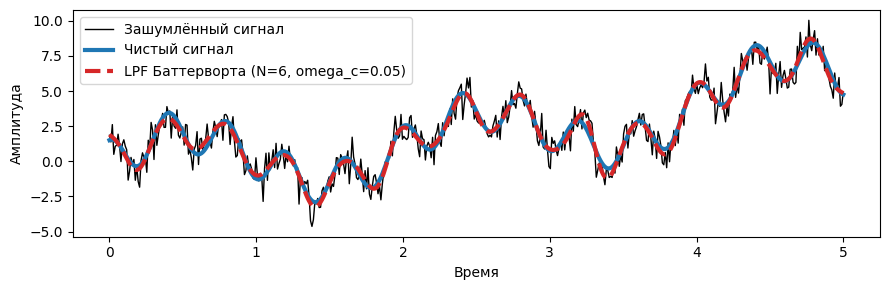

LPF Баттерворта: N=6, omega_c=0.08, MSE=0.085


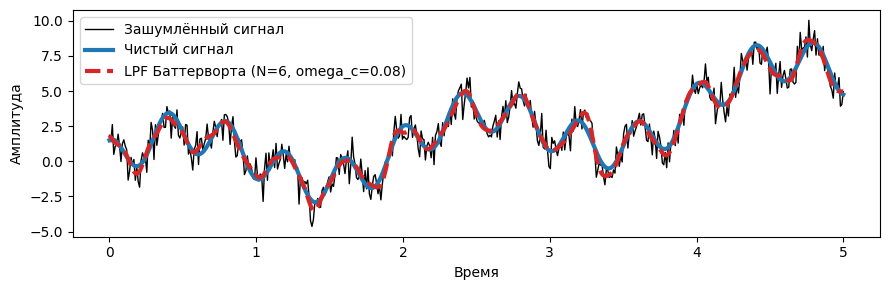


Лучшие параметры: N=6, omega_c=0.03, MSE=0.044


In [12]:
fs = 1 / (time[1] - time[0])  # частота дискретизации

best_mse = np.inf
best_params = None

for N in [1, 2, 4, 6]:
    for omega_c in [0.03, 0.05, 0.08]:
        b, a = signal.butter(N, omega_c * 2, btype='low')
        y_filtered = signal.filtfilt(b, a, noisy_signal)
        mse = np.mean((y_signal - y_filtered) ** 2)
        label = f'N={N}, omega_c={omega_c}'
        print(f"LPF Баттерворта: {label}, MSE={mse:.3f}")
        filter_plot(time, noisy_signal, y_signal, y_filtered,
                    ['Зашумлённый сигнал', 'Чистый сигнал', f'LPF Баттерворта ({label})'])
        if mse < best_mse:
            best_mse = mse
            best_params = (N, omega_c)

print(f"\nЛучшие параметры: N={best_params[0]}, omega_c={best_params[1]}, MSE={best_mse:.3f}")

Да, визуально лучший с N=6, фильтр достаточно крутой, хорошо режет шум, но без сильных искажений формы, синус сохранён, тренд не завален, шум ощутимо приглушён

При маленьком N (1,2) спад за частотой среза пологий, фильтр оставляет заметную часть высокочастотного шума, но почти не искажает форму синуса и тренда

При большом N (4-6) переходная полоса становится намного круче, шум сильнее подавляется, приближаясь к идеальномуфильтру, однако возрастает риск небольших искажений формы сигнала

### Упражнение 4

После HPF:


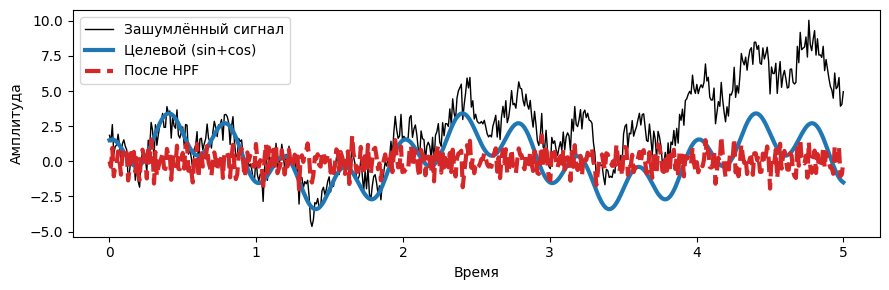

После каскада HPF + LPF:


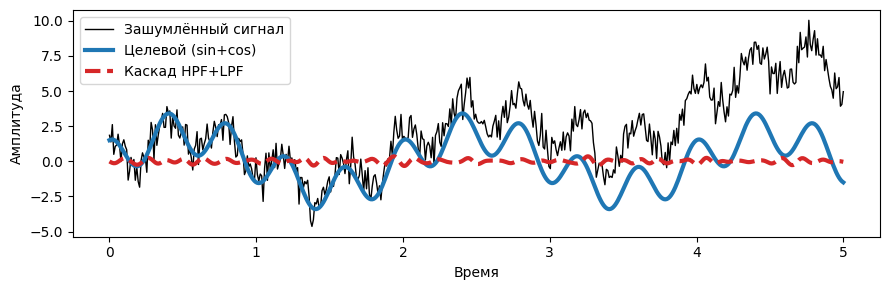

MSE каскада: 3.1312


In [13]:
# HPF удаляем тренд
N_hpf, omega_hpf = 4, 0.05
b_h, a_h = signal.butter(N_hpf, omega_hpf * 2, btype='high')
y_after_hpf = signal.filtfilt(b_h, a_h, noisy_signal)

print("После HPF:")
filter_plot(time, noisy_signal, y_sine + y_cos, y_after_hpf,
            ['Зашумлённый сигнал', 'Целевой (sin+cos)', 'После HPF'])

# LPF каскадно (удаляем шум)
N_lpf, omega_lpf = 4, 0.08
b_l, a_l = signal.butter(N_lpf, omega_lpf * 2, btype='low')
y_cascade = signal.filtfilt(b_l, a_l, y_after_hpf)

print("После каскада HPF + LPF:")
filter_plot(time, noisy_signal, y_sine + y_cos, y_cascade,
            ['Зашумлённый сигнал', 'Целевой (sin+cos)', 'Каскад HPF+LPF'])

mse_cascade = np.mean((y_sine + y_cos - y_cascade) ** 2)
print(f"MSE каскада: {mse_cascade:.4f}")

Завышение omega_c приводит к недостаточному подавлению шума, занижение к срезанию полезного сигнала (MSE=3.13). Качество каскада критически зависит от точного выбора частоты среза LPF
На краях временного ряда наблюдаются незначительные искажения, обусловленные граничными эффектами цифрового фильтра

### Упражнение 5

BPF Баттерворта:


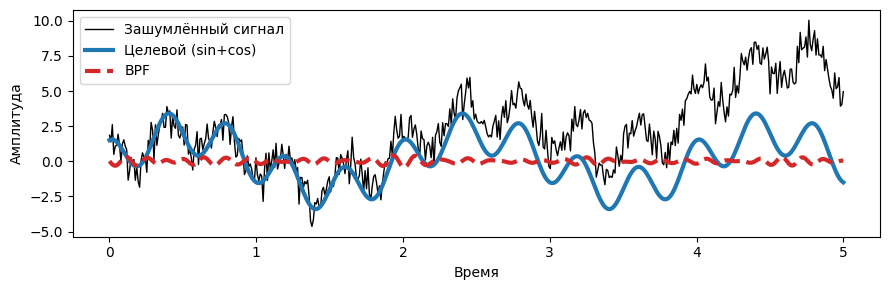

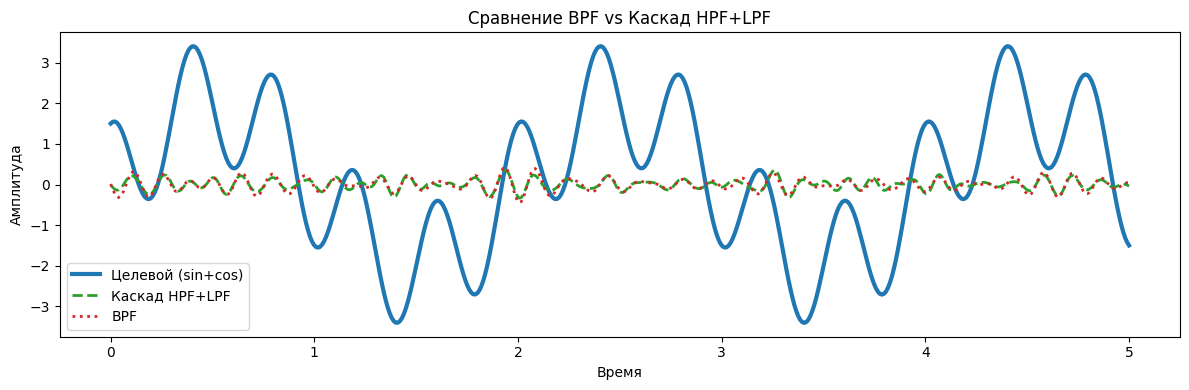

MSE BPF: 3.1504
MSE каскада: 3.1312


In [14]:
N_bpf = 4
omega_low  = 0.05   # нижняя граница (убираем тренд)
omega_high = 0.08   # верхняя граница (убираем шум)

b_bp, a_bp = signal.butter(N_bpf, [omega_low * 2, omega_high * 2], btype='bandpass')
y_bpf = signal.filtfilt(b_bp, a_bp, noisy_signal)

print("BPF Баттерворта:")
filter_plot(time, noisy_signal, y_sine + y_cos, y_bpf,
            ['Зашумлённый сигнал', 'Целевой (sin+cos)', 'BPF'])

# Сравнение BPF vs каскад
plt.figure(figsize=(12, 4))
plt.plot(time, y_sine + y_cos, 'tab:blue', lw=3, label='Целевой (sin+cos)')
plt.plot(time, y_cascade, 'tab:green', linestyle='--', lw=2, label='Каскад HPF+LPF')
plt.plot(time, y_bpf, 'tab:red', linestyle=':', lw=2, label='BPF')
plt.title('Сравнение BPF vs Каскад HPF+LPF')
plt.xlabel('Время')
plt.ylabel('Амплитуда')
plt.legend()
plt.tight_layout()
plt.show()

mse_bpf = np.mean((y_sine + y_cos - y_bpf) ** 2)
print(f"MSE BPF: {mse_bpf:.4f}")
print(f"MSE каскада: {mse_cascade:.4f}")

При текущих параметрах оба метода не восстанавливают полезный сигнал...
Разница незначительна (0.019), что говорит о плохом подгоне параметров....
Я попытался поиграться с параметрами в упражнении 1 и 4, но улучшения как будто бы были минимальными

### Упраженние 6

BSF — удаление y_cos (2.5 Гц):


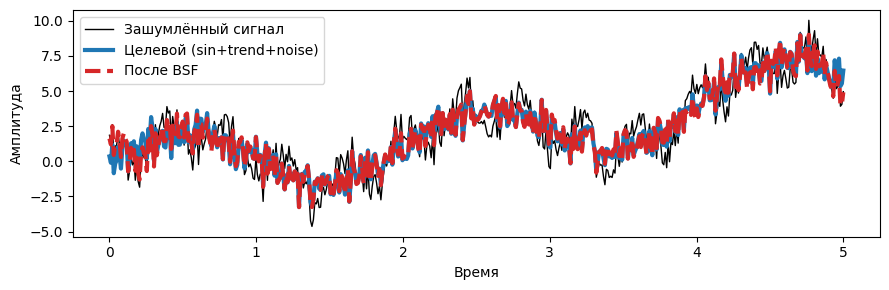

Частотная область до BSF:


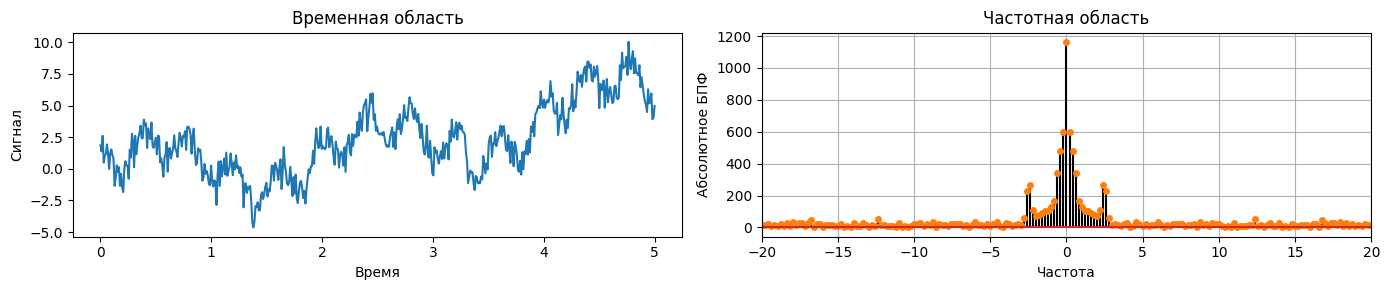

Частотная область после BSF:


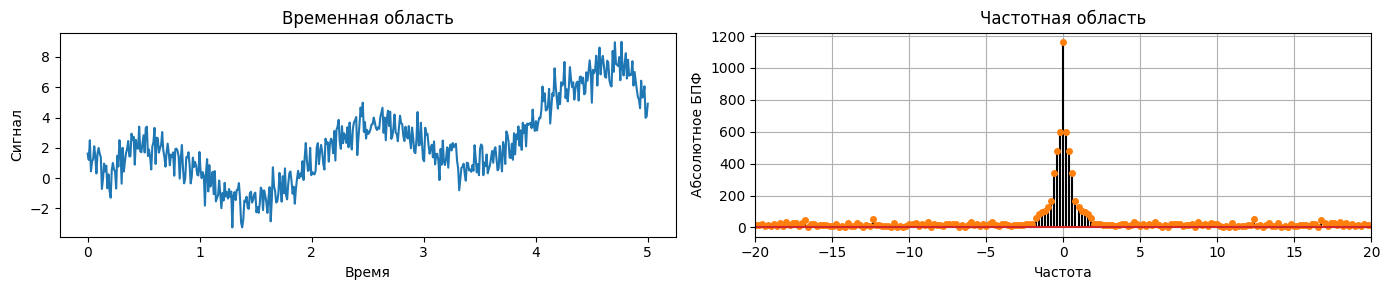

In [17]:
# y_cos имеет частоту 2.5Гц
# Нормализуем частота дискретизации fs
fs = 1 / (time[1] - time[0])
f_cos = 2.5  # Гц

# Полоса режекции 2.0–3.0 Гц
omega_bs_low  = (2.0 / (fs / 2))
omega_bs_high = (3.0 / (fs / 2))

N_bsf = 4
b_bs, a_bs = signal.butter(N_bsf, [omega_bs_low, omega_bs_high], btype='bandstop')
y_bsf = signal.filtfilt(b_bs, a_bs, noisy_signal)

y_target_bsf = y_sine + y_trend + y_noise  # что должно остаться

print("BSF — удаление y_cos (2.5 Гц):")
filter_plot(time, noisy_signal, y_target_bsf, y_bsf,
            ['Зашумлённый сигнал', 'Целевой (sin+trend+noise)', 'После BSF'])

print("Частотная область до BSF:")
plot_time_freq(time, noisy_signal)
print("Частотная область после BSF:")
plot_time_freq(time, y_bsf)

BSF вырезал частоту 1.5 Гц из зашумлённого сигнала, оставив тренд и шум нетронутыми

### Упражненение 7

Train: 86 точек, Test: 22 точек
n_harm= 1 - MSE=9.1728
n_harm= 2 - MSE=7.1025
n_harm= 3 - MSE=7.8223
n_harm= 5 - MSE=9.4011
n_harm=10 - MSE=9.8550
n_harm=20 - MSE=10.0698


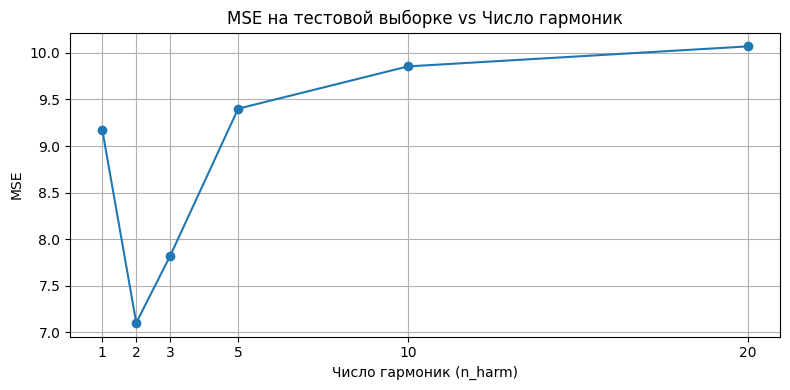


Лучшее число гармоник: 2, MSE=7.1025


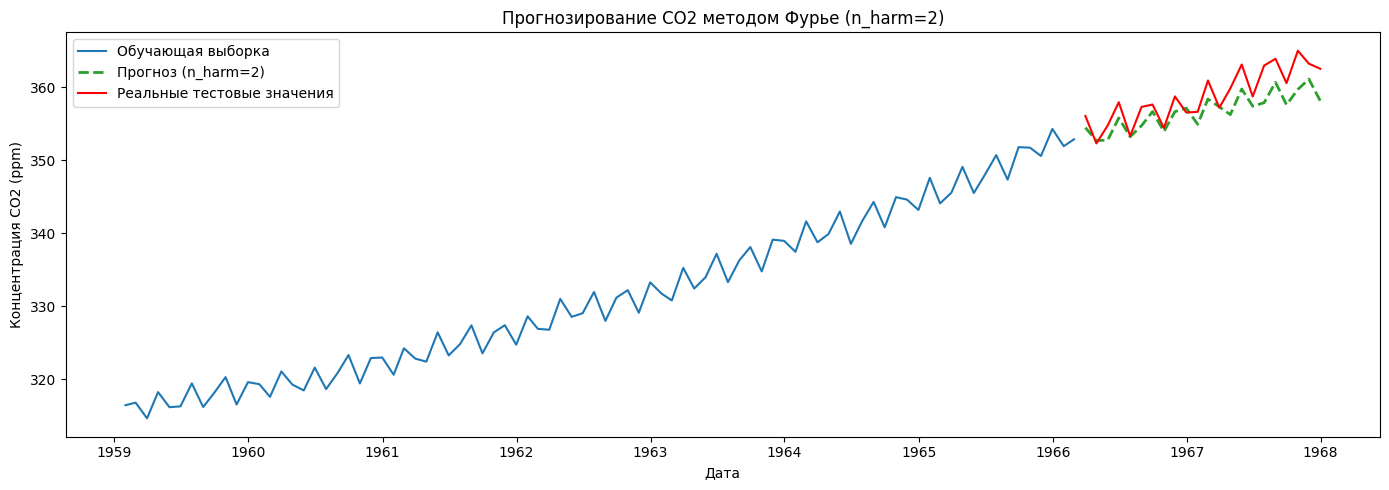

In [22]:
# Загрузка CO2
co2_data = sm.datasets.get_rdataset("CO2", "datasets").data
co2_data.index = pd.date_range(start='1959-01-01', periods=len(co2_data), freq='W')
# print(co2_data.columns)
# print(co2_data.head())
co2_data = co2_data.resample('ME').mean()
co2_series = co2_data['value'].dropna()


# Разбивка train/test
split = int(len(co2_series) * 0.8)
train = co2_series.iloc[:split]
test  = co2_series.iloc[split:]
n_predict = len(test)

print(f"Train: {len(train)} точек, Test: {len(test)} точек")

# Перебор гармоник
n_harm_list = [1, 2, 3, 5, 10, 20]
mse_list = []

for n_harm in n_harm_list:
    pred_full = fourierPrediction(train.values, n_predict=n_predict, n_harm=n_harm)
    pred_test = pred_full[len(train):]
    mse = np.mean((test.values - pred_test) ** 2)
    mse_list.append(mse)
    print(f"n_harm={n_harm:2d} - MSE={mse:.4f}")

# График MSE vs n_harm
plt.figure(figsize=(8, 4))
plt.plot(n_harm_list, mse_list, 'o-', color='tab:blue')
plt.title('MSE на тестовой выборке vs Число гармоник')
plt.xlabel('Число гармоник (n_harm)')
plt.ylabel('MSE')
plt.xticks(n_harm_list)
plt.grid()
plt.tight_layout()
plt.show()

# Лучший прогноз
best_n_harm = n_harm_list[np.argmin(mse_list)]
print(f"\nЛучшее число гармоник: {best_n_harm}, MSE={min(mse_list):.4f}")

pred_best = fourierPrediction(train.values, n_predict=n_predict, n_harm=best_n_harm)

plt.figure(figsize=(14, 5))
plt.plot(train.index, train.values, label='Обучающая выборка', color='tab:blue')
plt.plot(test.index, pred_best[len(train):], label=f'Прогноз (n_harm={best_n_harm})',
         color='tab:green', linestyle='--', lw=2)
plt.plot(test.index, test.values, label='Реальные тестовые значения', color='red')
plt.title(f'Прогнозирование CO2 методом Фурье (n_harm={best_n_harm})')
plt.xlabel('Дата')
plt.ylabel('Концентрация CO2 (ppm)')
plt.legend()
plt.tight_layout()
plt.show()

Оптимальное число гармоник: 2

Первые две гармоники адекватно описывают годовую сезонность ряда. Увеличение числа гармоник свыше 2 приводит к переобучению